# Multi-Task NLP Assistant — Inline Colab Version

This notebook shows all outputs directly inside Colab cells. It includes sentiment analysis, abstractive summarization, and extractive question answering.

Use **Runtime → Change runtime type → T4 GPU** before loading the models.

loads three independent pretrained Transformer models:


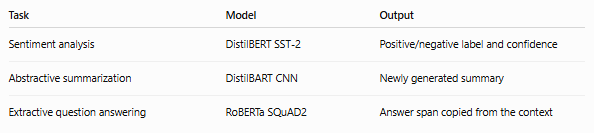

The workflow is:

* Install the required libraries.
* Detect whether a GPU is available.
* Load three pretrained task-specific models.
* Define an inference function for each task.
* Run fixed examples.
* User can edit variables and try custom examples.
* Display all results directly in Colab.




It does not train or fine-tune any model.

In [ ]:
%pip uninstall -y torchao torchvision timm
%pip install -q -U "transformers>=5,<6" "accelerate>=1.10,<2" "sentencepiece>=0.2,<1"

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: timm 1.0.28
Uninstalling timm-1.0.28:
  Successfully uninstalled timm-1.0.28
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 132.7 MB/s eta 0:00:00


In [ ]:
import torch
import transformers

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIPELINE_DEVICE = 0 if torch.cuda.is_available() else -1

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Device:", DEVICE)

PyTorch: 2.11.0+cu128
Transformers: 5.14.1
Device: cuda


## Load the models

In [ ]:
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForQuestionAnswering,
)

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    device=PIPELINE_DEVICE,
)

SUMMARIZATION_MODEL = "sshleifer/distilbart-cnn-12-6"
summarization_tokenizer = AutoTokenizer.from_pretrained(SUMMARIZATION_MODEL)
summarization_model = AutoModelForSeq2SeqLM.from_pretrained(
    SUMMARIZATION_MODEL
).to(DEVICE)
summarization_model.eval()

QA_MODEL = "deepset/roberta-base-squad2"
qa_tokenizer = AutoTokenizer.from_pretrained(QA_MODEL)
qa_model = AutoModelForQuestionAnswering.from_pretrained(
    QA_MODEL
).to(DEVICE)
qa_model.eval()

print("Models loaded successfully.")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  496MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Models loaded successfully.


## Helper functions

The helper functions make the already-loaded models easy and safe to use. They do not train the models; they package the repeated inference steps into reusable functions.

In [ ]:
def analyze_sentiment(text):
    text = (text or "").strip()
    if not text:
        return {"label": "N/A", "score": 0.0}

    result = sentiment_pipe(text[:2000])[0]
    return {
        "label": result["label"],
        "score": round(float(result["score"]), 4),
    }
# Function : analyze_sentiment()
# Purpose: classify text as positive or negative.

# It:

# 1. Cleans the input using .strip().
# 2. Handles empty input.
# 3. sends the text to sentiment_pipe.
# 4. Returns the label and confidence score.

def summarize_text(text, max_length=130, min_length=30):
    text = (text or "").strip()
    if not text:
        return "Please enter text to summarize."

    inputs = summarization_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=1024,
    ).to(DEVICE)

    with torch.inference_mode():
        output_ids = summarization_model.generate(
            **inputs,
            max_new_tokens=int(max_length),
            min_new_tokens=int(min_length),
            num_beams=4,
            no_repeat_ngram_size=3,
            length_penalty=2.0,
            early_stopping=True,
        )

    return summarization_tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True,
    ).strip()
# Function: summarize_text()
# Purpose: generate a shorter version of a passage.

# It:

# Checks that text was supplied.
# Tokenizes the passage.
# Moves the tokens to the model’s device.
# Generates a summary without calculating gradients.
# Decodes the generated tokens into readable text.
def answer_question(question, context, confidence_threshold=0.15):
    question = (question or "").strip()
    context = (context or "").strip()

    if not question or not context:
        return {
            "answer": "Please provide both a question and a context passage.",
            "confidence": 0.0,
        }

    encoded = qa_tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation="only_second",
        max_length=512,
        return_offsets_mapping=True,
    )

    offsets = encoded.pop("offset_mapping")[0]
    sequence_ids = encoded.sequence_ids(0)
    model_inputs = {k: v.to(DEVICE) for k, v in encoded.items()}

    with torch.inference_mode():
        outputs = qa_model(**model_inputs)

    start_logits = outputs.start_logits[0]
    end_logits = outputs.end_logits[0]
    # The QA model produces two arrays:
    # These assign scores to every token as a possible:

    # Start of the answer
    # End of the answer

    # The code masks question tokens so that answers can only be selected from the context:

    context_mask = torch.tensor(
        [sid == 1 for sid in sequence_ids],
        dtype=torch.bool,
        device=DEVICE,
    )

    neg_inf = torch.finfo(start_logits.dtype).min
    masked_start = start_logits.masked_fill(~context_mask, neg_inf)
    masked_end = end_logits.masked_fill(~context_mask, neg_inf)

    top_k = 20
    start_ids = torch.topk(masked_start, k=min(top_k, len(masked_start))).indices.tolist()
    end_ids = torch.topk(masked_end, k=min(top_k, len(masked_end))).indices.tolist()

    best = None
    best_score = float("-inf")

    for s in start_ids:
        for e in end_ids:
            if e < s or e - s + 1 > 40:
                continue
            score = float(start_logits[s] + end_logits[e])
            if score > best_score:
                best_score = score
                best = (s, e)

    if best is None:
        return {
            "answer": "The answer is not confidently supported by the context.",
            "confidence": 0.0,
        }

    s, e = best
    start_char = int(offsets[s][0])
    end_char = int(offsets[e][1])

    # It then searches among the top 20 start and end positions and rejects:

    # End positions before the start
    # Answers longer than 40 tokens

    # Finally, offsets convert the selected token positions back into characters from the original context:

    answer = context[start_char:end_char].strip()

    #This is more educational than simply calling:  pipeline("question-answering") because it exposes how extractive QA works internally.

    start_prob = torch.softmax(masked_start, dim=-1)[s]
    end_prob = torch.softmax(masked_end, dim=-1)[e]
    confidence = float(torch.sqrt(start_prob * end_prob))

    if not answer or confidence < confidence_threshold:
        answer = "The answer is not confidently supported by the context."

    return {
        "answer": answer,
        "confidence": round(confidence, 4),
    }
# Function:  answer_question()
# Purpose: extract an answer from a supplied context passage.

# It:

# Validates the question and context.
# Tokenizes them together.
# Runs the QA model.
# obtains possible start and end positions.
# restricts the answer search to the context.
# Finds the best valid answer span.
# Converts that token span back into text.
# Returns the answer and an estimated confidence.

## 1. Sentiment analysis — inline output

This introduces classification using a ready-made Hugging Face pipeline.

Unlike translation or summarization, it does not generate text. It predicts.

In [ ]:
examples = [
    "I am very happy with the results.",
    "This process has been extremely frustrating.",
    "The application works, but the interface is ordinary.",
]

for text in examples:
    result = analyze_sentiment(text)
    print("Text:", text)
    print("Result:", result)
    print("-" * 80)

Text: I am very happy with the results.
Result: {'label': 'POSITIVE', 'score': 0.9999}
--------------------------------------------------------------------------------
Text: This process has been extremely frustrating.
Result: {'label': 'NEGATIVE', 'score': 0.9986}
--------------------------------------------------------------------------------
Text: The application works, but the interface is ordinary.
Result: {'label': 'POSITIVE', 'score': 0.9678}
--------------------------------------------------------------------------------


## 2. Summarization — inline output

In [ ]:
article = """
Low-rank adaptation is a parameter-efficient method for adapting large
pretrained language models. Instead of updating every model parameter,
LoRA inserts small trainable low-rank matrices into selected layers.
The original model weights remain frozen. This reduces memory use and
makes it practical to store separate adapters for multiple tasks.
"""

summary = summarize_text(article, max_length=80, min_length=20)

print("Original text:")
print(article.strip())
print("\nGenerated summary:")
print(summary)

[transformers] Both `max_new_tokens` (=80) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=20) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Original text:
Low-rank adaptation is a parameter-efficient method for adapting large
pretrained language models. Instead of updating every model parameter,
LoRA inserts small trainable low-rank matrices into selected layers.
The original model weights remain frozen. This reduces memory use and
makes it practical to store separate adapters for multiple tasks.

Generated summary:
Instead of updating every model parameter, LoRA inserts small trainable low-rank matrices into selected layers . This reduces memory use and makes it practical to store separate adapters for multiple tasks .


## 3. Question answering — inline output

In [ ]:
# The QA model produces two arrays:
# These assign scores to every token as a possible:

# Start of the answer
# End of the answer

# The code masks question tokens so that answers can only be selected from the context:
# It then searches among the top 20 start and end positions and rejects:

# End positions before the start
# Answers longer than 40 tokens

# Finally, offsets convert the selected token positions back into characters from the original context:
#This is more educational than simply calling:  pipeline("question-answering") because it exposes how extractive QA works internally

In [ ]:
context = """
The National Informatics Centre was established in 1976.
It provides information and communication technology services
to government departments in India.
"""

question = "When was the National Informatics Centre established?"
result = answer_question(question, context)

print("Context:")
print(context.strip())
print("\nQuestion:", question)
print("Answer:", result["answer"])
print("Confidence:", result["confidence"])

Context:
The National Informatics Centre was established in 1976.
It provides information and communication technology services
to government departments in India.

Question: When was the National Informatics Centre established?
Answer: 1976
Confidence: 0.9965


## 4. Try your own inputs

In [ ]:
custom_sentiment_text = "The revised notebook is much easier to use."

custom_article = """
Artificial intelligence systems can perform several language-processing
tasks, including classification, summarization, and question answering.
Modern transformer libraries provide pretrained models that make these
tasks easier to demonstrate with relatively little code.
"""

custom_context = """
Google Colab is a hosted notebook environment that can provide access
to CPUs, GPUs, and TPUs. It is commonly used for teaching, experimentation,
and prototyping machine-learning workflows.
"""

custom_question = "What is Google Colab commonly used for?"

print("SENTIMENT")
print(analyze_sentiment(custom_sentiment_text))

print("\nSUMMARY")
print(summarize_text(custom_article, max_length=70, min_length=15))

print("\nQUESTION ANSWERING")
print(answer_question(custom_question, custom_context))

[transformers] Both `max_new_tokens` (=70) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=15) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SENTIMENT
{'label': 'POSITIVE', 'score': 0.9667}

SUMMARY
Transformer libraries provide pretrained models that make these tasks easier to demonstrate with relatively little code .

QUESTION ANSWERING
{'answer': 'teaching, experimentation,\nand prototyping machine-learning workflows', 'confidence': 0.8806}
